## Setup

### Import Libraries

In [1]:
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import numpy as np
from torch import optim

### Generate Data

Text(0, 0.5, 'y')

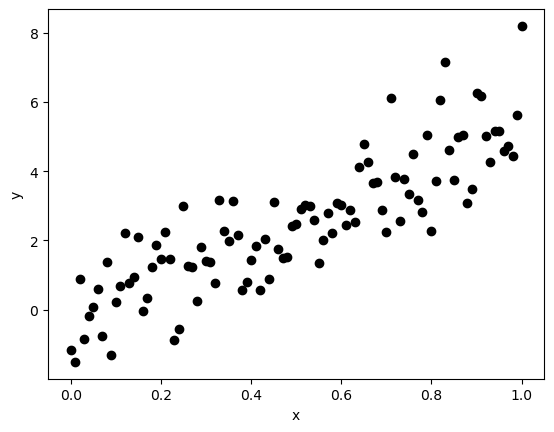

In [17]:
torch.manual_seed(2025)

x = torch.linspace(0,1,101).unsqueeze(1)

y_obs = 5*x + torch.randn_like(x)

plt.plot(x, y_obs, 'o', color='black')
plt.xlabel("x")
plt.ylabel("y")

## Section 1: Creating a Model and Calculate the Prediction Loss

| Code | Description |
| --- | --- |
| `nn.Linear(n_features_in, n_features_out)` | A single layer that takes in `n_features_in` input features and outputs `n_features_out` features.|
| `model(X_input)` | Pass input `X_input` to a neuronal network `model`. |
| `y_pred = model(X_input)` | Pass input `X_input` to a neuronal network `model` and assign the output to a variable `y_pred`. |
| `(y_pred-y_obs).square().mean()` | Calculate the mean squared error of the model prediction `y_pred` compared to the observed data `y_obs`. |
| `loss_function = nn.MSELoss()` | Creates a mean squared error (MSE) loss function and assigns it to a variable named `loss_function`. |
| `loss_function(y_pred, y_obs)` | Calculates the loss between the output of the network `y_pred` and the observed y-values from the data `y_obs`. |
| `loss_function(y_pred, y_obs).item()` | Extracts the loss value - i.e. the number alone as a ``float`` and not as a ``tensor``. |

**Demo**: Run the cell below to see a demonstration of how pytorch can be used to do linear regression. We'll learn how to do each of these steps in the following sections.

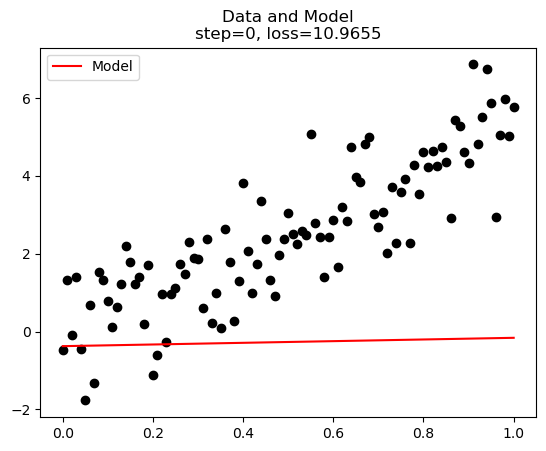

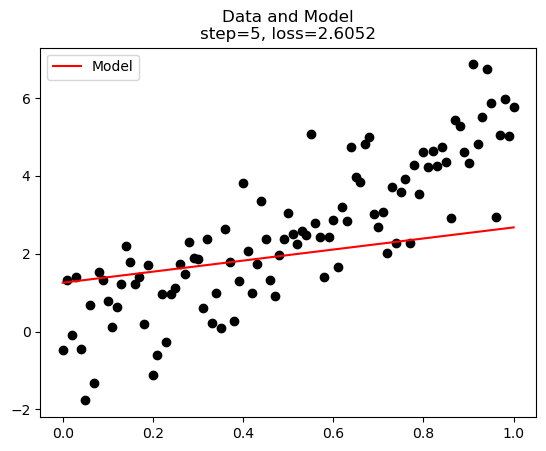

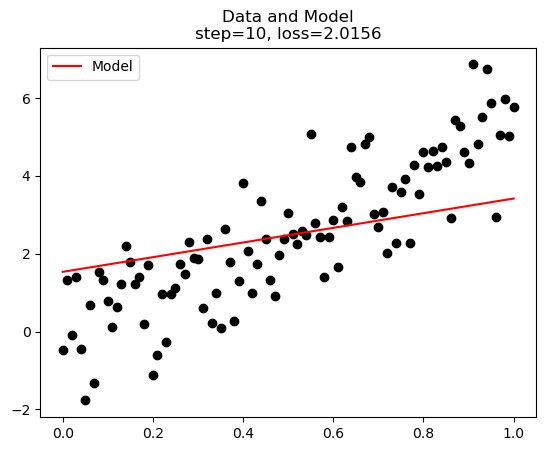

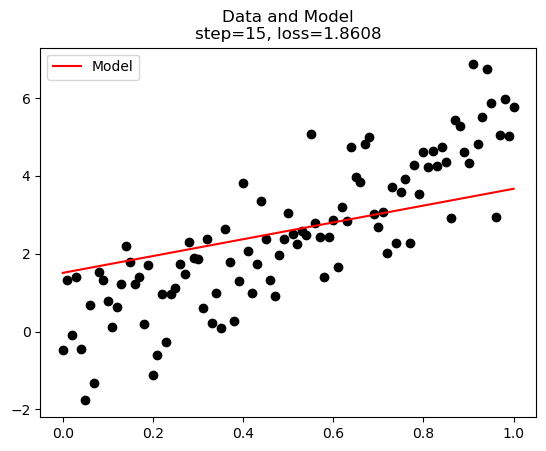

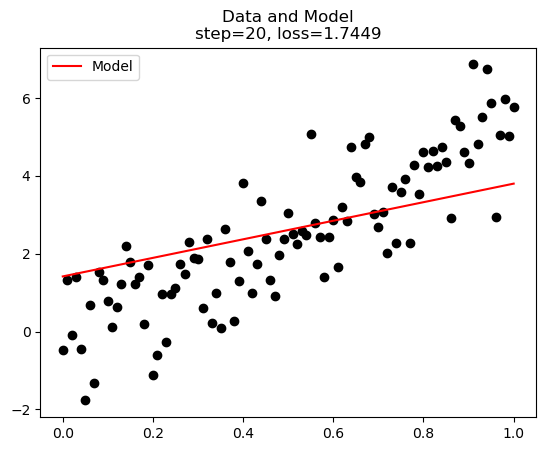

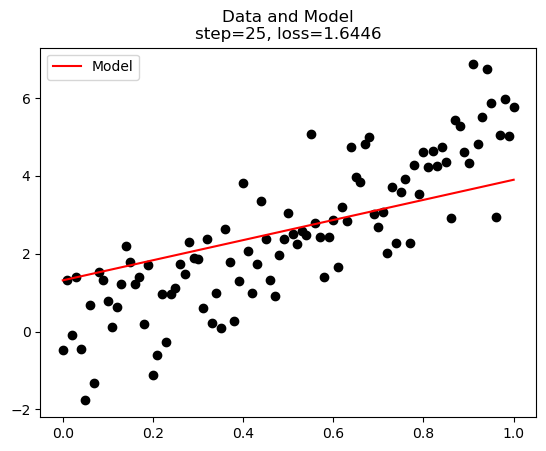

In [6]:
# create model
model = nn.Linear(1,1)

# create optimizer
optimizer = optim.SGD(model.parameters(), lr=0.1)

# optimize model through iterative guessing and parameter updates
for step in range(26):
    # reset gradients
    optimizer.zero_grad()

    # predict output with model
    y_pred = model(x)

    # calculate prediction loss
    loss = (y_pred-y_obs).square().mean()

    # plot the data and the model
    if (step % 5) == 0:
        plt.figure()
        plt.title(f"Data and Model\nstep={step}, loss={loss:.4f}")
        plt.plot(x, y_obs, "o", color="black")
        plt.plot(x, model.weight.item()*x + model.bias.item(), color="r", label="Model")
        #plt.plot(x, y_pred.detach().numpy())
        plt.legend()

    # do backpropagation to get gradients
    loss.backward()

    # update model parameters
    optimizer.step()

**Example**: Create a single layer model with 2 input features and 16 output features.

In [62]:
nn.Linear(2, 16)

Linear(in_features=2, out_features=16, bias=True)

**Exercise**: Create a single layer model with 1 input feature and 8 output features.


In [63]:
nn.Linear(1,8)

Linear(in_features=1, out_features=8, bias=True)

**Exercise**: Create a single layer model with 20 input feature and 2 output features and assign it to a variable called `model`. Print the `model` variable.


In [44]:
model = nn.Linear(20,8)
print(model)

Linear(in_features=20, out_features=8, bias=True)


**Exercise**: Pass the random input generated below to the model.

The output from the model should look like this:

`tensor([ 0.3933,  0.1313,  0.7289, -0.7033,  0.0142, -0.2668, -0.3853,  0.9032],
       grad_fn=<ViewBackward0>)`

In [45]:
torch.manual_seed(2025)
input = torch.randn(20)
input

tensor([-1.1607, -1.5591,  0.7782, -0.9990,  0.4670,  1.1802,  0.3709, -2.0193,
        -1.1871, -0.2822, -0.2651,  2.7671, -1.1414,  0.3533, -0.0972, -0.1674,
         0.9320, -0.7882, -2.8070,  0.5447])

In [46]:
model(input)

tensor([ 0.3933,  0.1313,  0.7289, -0.7033,  0.0142, -0.2668, -0.3853,  0.9032],
       grad_fn=<ViewBackward0>)

**Exercise**: Run the cell below to generate a new random input. Try to pass this input to the model. What does the error message you get say?

In [47]:
torch.manual_seed(2025)
input = torch.randn(25)
input

tensor([-1.1607, -1.5591,  0.7782, -0.9990, -0.3729, -0.1594,  0.2836, -1.1234,
         0.9813, -0.2822, -0.2651,  2.7671,  0.8749, -0.1597, -1.5970, -0.7229,
        -0.8230, -0.7882, -2.8070,  0.5447, -1.6047,  0.2632, -1.9616, -0.9576,
        -0.5698])

In [48]:
model(input)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x25 and 20x8)

Presumably, you got the following error message: "RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x25 and 20x8)".

You got this error because the dimensions of the input (1x25) don't match the number of input features in the model (which is 20).

This error message reveals an important fact about passing inputs through a neural network model: It's a matrix multiplication! And when you do matrix multiplication, the dimensions of the matrices (along which the multiplication is carried out) have to match. To fix the issue above, you can create a new model with 25 input features.

**Exercise**: Create a single layer with 25 input features and 2 output features and assign it to a variable called `model`. Then pass the same random input to the model as in the previous exercise. Did it run through now?

In [59]:
model = nn.Linear(25,8)
model(input)

tensor([ 0.4385,  0.0260,  0.6803, -0.6616, -0.3066, -0.0781, -0.1993, -0.2913],
       grad_fn=<ViewBackward0>)

In the cell below, a very simple model with a single input and output feature is created. Then, the `x` data generated in the setup section is passed to it.

**Exercise**: Calculate the mean square error of the model prediction `y_pred` (compare to the observed data `y_obs`). This is the prediction loss.

**Hint**: See reference table. 

The output should look like this:

`tensor(5.5301, grad_fn=<MeanBackward0>)`

In [62]:
torch.manual_seed(2025)

model = nn.Linear(1,1)
y_pred = model(x)

In [63]:
(y_pred-y_obs).square().mean()

tensor(5.5301, grad_fn=<MeanBackward0>)

**Exercise**: Create a loss function using `torch`'s function `nn.MSELoss()` and assign it to a variable named `loss_function`.

In [64]:
loss_function = nn.MSELoss()

**Exercise**: Calculate the same mean square error loss of the prediction `y_pred` using the loss function you created in the previous exercise.

In [65]:
loss_function(y_pred, y_obs)

tensor(5.5301, grad_fn=<MseLossBackward0>)

**Exercise**: Extract the number from the loss you calculated in the previous exercise from the tensor.

**Hint**: `.item()`

In [66]:
loss_function(y_pred, y_obs).item()

5.530094146728516

## Section 2: Optimize Model Parameters

We have created a model, passed input to the model to get a prediction, and calculated the loss (error) of the prediction. The next step  in regression is to optimize the parameters of the model based on that loss. In the previous session, we implemented the optimization method called *gradient descent* ourselves. However, PyTorch provides a package called `optim` that can be used to create optimizer objects that different kinds of optimization methods for us.

**Standard gradient descent**

$$
w_{t+1} = w_{t} - \eta \nabla L(w)
$$

for weight parameters $w_{i}$ at time step (epoch) $t$, where $L$ is loss function to be minimized and $\eta$ is the learning parameter.

Written differently:

$$
w_{t+1} = w_{t} - \eta \frac{1}{N}\sum_{j}^{N}\nabla l(y_{j}, f_{w}(x_{j}))
$$

| Code | Description |
| --- | --- |
| `optim.SGD(model.parameters())` | Creates a gradient descent optimizer. |
| `optim.SGD(model.parameters(), lr=0.01, momentum = 0.99)` | Creates a gradient descent optimizer with a learning rate `lr` of 0.01 (the default value is 0.001) and ``momentum`` of 0.99 (the default value is 0.9). |
| `optimizer.zero_grad()` | Resets the gradients before the next iteration in the optimization. |
| `loss.backward()`| Performs backward propagation and calculates the gradients through the graph leaves (network). |
| `optimizer.step()` | Update the parameters of the network. |
| `for epoch in range(10):` <br> &nbsp;&nbsp;&nbsp;&nbsp; `print(epoch)` | Print every number `epoch` between 0 and 10 (not including 5)|

Run the cell below to create a model with a single input feature and a single output feature.

In [84]:
torch.manual_seed(2025)
model = nn.Linear(1,1)
model.weight

Parameter containing:
tensor([[0.3699]], requires_grad=True)

**Example**: Create a gradient descent optimizer for the model defined in the cell above. Assign it to a variable named `optimizer`.

In [85]:
optimizer = optim.SGD(model.parameters())
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

**Exercise**: Create a stochastic gradient descent optimizer with a learning rate of `0.1` for the same model. Assign it to a variable named `optimizer`.

In [86]:
optimizer = optim.SGD(model.parameters(), lr=0.1)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

Run the cell below to pass the input to the model, create an MSE loss function, and calculate the loss of the model prediction.

In [87]:
# pass input to model
y_pred = model(x)

# create a loss function
loss_function = nn.MSELoss()

# calculate loss of 
loss = loss_function(y_pred, y_obs)
loss

tensor(5.5301, grad_fn=<MseLossBackward0>)

**Exercise**: Do backpropagation on the loss computed in the cell above. This automatically calculates the gradients for all parameters (weights) of the model.

In [88]:
loss.backward()

**Exercise**: Now that the gradients have been calculated, you can update the model parameters using the `.step()` function of the `optimizer`. After updating the parameters, run the cell below that gets the `weight` parameter of the model. Is it different from the initial `weight` parameter printed at the very beginning of this section?

In [89]:
optimizer.step()

In [90]:
model.weight

Parameter containing:
tensor([[0.6063]], requires_grad=True)

Run the cell below that gets the gradient of the weight parameter.

In [91]:
model.weight.grad

tensor([[-2.3636]])

**Exercise**: Reset the gradients of model with the optimizer. Then, run the cell below that gets the gradient of the weight parameter again. This time, nothing will be displayed (if you solved this exercise correctly). Why is that, do you think?

In [92]:
optimizer.zero_grad()

In [93]:
model.weight.grad

**Exercise**: Put the following code in a loop of 5 epochs.

In [177]:
# reset the gradients
optimizer.zero_grad()

# pass the input to the network
y_model = model(x)

# calculate the loss
loss = loss_function(y_model, y_obs)

# perform backward propagation to calculate the gradients
loss.backward()

# update the parameters
optimizer.step()

print(f"loss = {loss.item()}")

loss = 1.716313123703003


In [94]:
for epoch in range(5):
    # reset the gradients
    optimizer.zero_grad()
    
    # pass the input to the network
    y_model = model(x)

    # calculate the loss
    loss = loss_function(y_model, y_obs)

    # perform backward propagation to calculate the gradients
    loss.backward()

    # update the parameters
    optimizer.step()

    print(f"loss = {loss.item()}")

loss = 4.288543701171875
loss = 3.5765299797058105
loss = 3.1600751876831055
loss = 2.9088101387023926
loss = 2.750088930130005


## Section 3: Visualize Model Performance Trhoughout Training

Above, we printed the loss in each iteration of the model optimization. It's often useful to store the loss and plot it to visualize how it develops throughout training.

| Code | Description |
| --- | --- |
| `new_list = []` or `new_list = list()`| Initialize an empty list named `new_list` |
| `new_list.append(element)`| Append an element to the list `new_list` |
| `loss_function(y_pred, y_obs).item()` | Extracts the loss value - i.e. the number alone as a ``float`` and not as a ``tensor``. |
| `plt.plot(a, b)`| Plot the elements of `a` against the elements of `b`. |

**Exercise**: Fill in the blank line in the code below to store the loss calculated in each iteration during training.

**Hint**: Remember to get extract the value from the loss when storing it in a list.

In [ ]:
# create model
torch.manual_seed(2025)
model = nn.Linear(1,1)

# create optimizer
optimizer = torch.optim.SGD(model.parameters(), lr = 0.1)

# initilize empty list to store the calculated loss in each iteration
losses = []

for epoch in range(5):
    # reset the gradients
    optimizer.zero_grad()
    
    # pass the input to the network
    y_model = model(x)

    # calculate the loss
    loss = loss_function(y_model, y_obs)

    # store losses in list
    ___

    # perform backward propagation to calculate the gradients
    loss.backward()

    # update the parameters
    optimizer.step()

    print(f"loss = {loss.item()}")

In [ ]:
# create model
torch.manual_seed(2025)
model = nn.Linear(1,1)

# create optimizer
optimizer = torch.optim.SGD(model.parameters(), lr = 0.1)

# initilize empty list to store the calculated loss in each iteration
losses = []

for epoch in range(5):
    # reset the gradients
    optimizer.zero_grad()
    
    # pass the input to the network
    y_model = model(x)

    # calculate the loss
    loss = loss_function(y_model, y_obs)

    # store losses in list
    losses.append(loss.item())

    # perform backward propagation to calculate the gradients
    loss.backward()

    # update the parameters
    optimizer.step()

    print(f"loss = {loss.item()}")

loss = 5.530094146728516
loss = 4.288543701171875
loss = 3.5765299797058105
loss = 3.1600751876831055
loss = 2.9088101387023926
loss = 2.750088930130005
loss = 2.643425464630127
loss = 2.5662498474121094
loss = 2.5059752464294434
loss = 2.4555773735046387
loss = 2.4111294746398926
loss = 2.3704328536987305
loss = 2.3322501182556152
loss = 2.295881509780884
loss = 2.260925531387329


**Exercise**: Plot the losses. The epoch number will be on the x-axis.

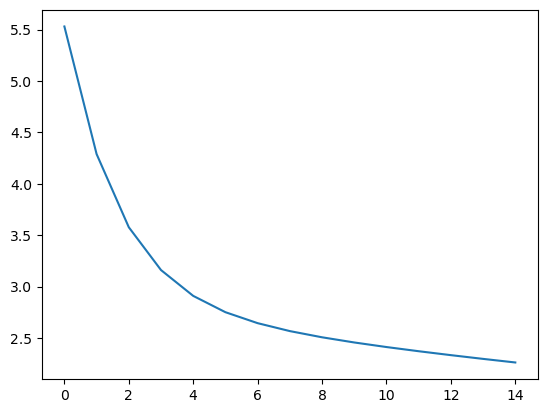

In [101]:
plt.plot(losses)

**Exercise**: Try increasing the number of epochs to 10 or higher, run the training, and plot the losses again. What happens to the loss curve as you increase the epochs?

In [ ]:
plt.plot(losses)

**Example**: Below, we put the training of the model inside a function called `do_ml_regression` with two parameters: `data`, which is the input data, and the `learning_rate`. The function returns the `losses` computed throughout the training. Use the function to do the training of the model and plot the losses when the learning rate is set to `0.1`.

**TODO**: Make it a utility function and put it in setup instead.

In [109]:
def do_ml_regression(data, learning_rate = 0.1):
    # create model
    torch.manual_seed(2025)
    model = nn.Linear(1,1)

    # create optimizer
    optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)

    # initilize empty list to store the calculated loss in each iteration
    losses = []

    for epoch in range(50):
        # reset the gradients
        optimizer.zero_grad()
        
        # pass the input to the network
        y_model = model(data)

        # calculate the loss
        loss = loss_function(y_model, y_obs)

        # store losses in list
        losses.append(loss.item())

        # perform backward propagation to calculate the gradients
        loss.backward()

        # update the parameters
        optimizer.step()

    return losses

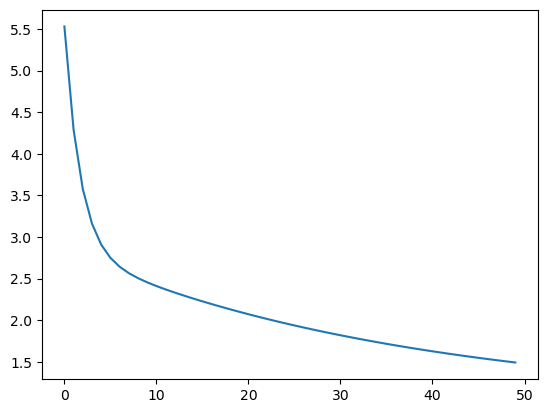

In [110]:
losses = do_ml_regression(x, learning_rate = 0.1)

plt.plot(losses)

**Exercise**: Use the `do_ml_regression` function to do the regression again, but this time, set the `learning_rate` to `0.01`. Plot the losses. Does the model appear to learn faster or slower?

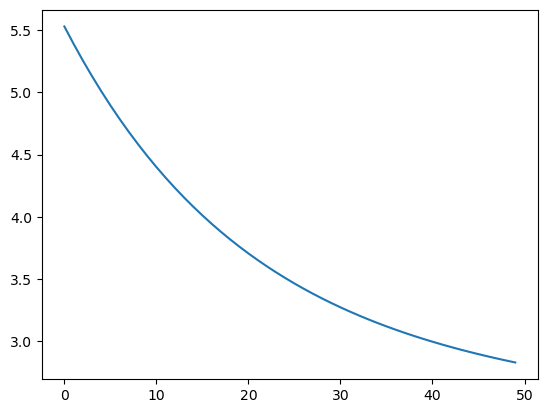

In [111]:
losses = do_ml_regression(x, learning_rate = 0.01)

plt.plot(losses)

**Exercise**: Use the `do_ml_regression` function to do the regression again, but this time, set the `learning_rate` to `1`. Plot the losses. What happens to the loss throughout training now?

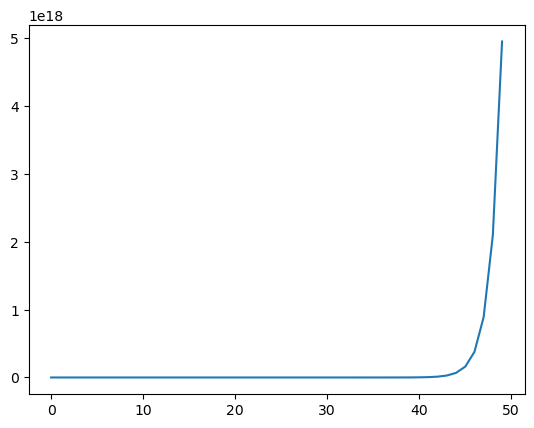

In [112]:
losses = do_ml_regression(x, learning_rate = 1)

plt.plot(losses)

## Section 4: Training hyperparameters (only learning rate for now)